AQI data shape: (1097, 15)
Total satellite images found: 544


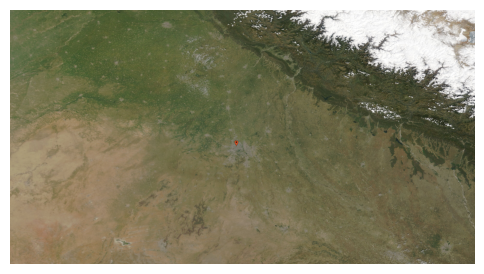

Processed image shape: (544, 224, 224, 3)
Matched records: (544, 15)


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,2020-04-01,30.7,265.3,167.6,1.5,135.7,13.4,3.37,85.9,14.5,2.18,13.81,3.20,17.3,Severe
1,2020-04-03,41.2,311.9,66.4,145.0,138.3,18.7,3.46,87.6,64.5,7.18,15.50,4.09,67.5,Satisfactory
2,2020-04-05,0.8,46.4,38.6,65.8,63.6,8.2,2.40,21.6,56.7,7.31,20.48,1.52,17.5,Severe
3,2020-04-07,410.6,138.3,105.2,76.5,147.7,0.4,6.56,90.8,68.6,18.36,29.69,8.75,25.6,Severe
4,2020-04-09,114.6,519.5,179.6,100.2,78.7,6.3,7.75,20.6,138.4,10.83,7.74,4.35,75.2,Very Poor


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# ======================
# LOAD AQI DATA
# ======================
df = pd.read_csv("../data/cleaned_aqi_final.csv")
df['Date'] = pd.to_datetime(df['Date'])

df = df[df['Date'].dt.year.isin([2020, 2021, 2024])]

print("AQI data shape:", df.shape)

# ======================
# LOAD IMAGES
# ======================
base_folder = "../satellite images"

image_paths = []

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))

print("Total satellite images found:", len(image_paths))

# ======================
# SAMPLE IMAGE
# ======================
img = Image.open(image_paths[0])

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

# ======================
# PROCESS IMAGES
# ======================
IMG_SIZE = (224, 224)

processed_images = []
image_dates = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img) / 255.0

    processed_images.append(img)

    filename = os.path.basename(path)
    date_part = filename.split(".")[0]

    image_dates.append(pd.to_datetime(date_part))

processed_images = np.array(processed_images)

print("Processed image shape:", processed_images.shape)

# ======================
# MATCH WITH AQI
# ======================
image_df = pd.DataFrame({
    "Date": image_dates
})

merged_df = pd.merge(image_df, df, on="Date", how="inner")

print("Matched records:", merged_df.shape)

merged_df.head()